In [ ]:
# 3rd party imports
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

# Logging setup
logger = logging.getLogger()
logger.handlers.clear()
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.INFO)
logger.addHandler(stream_handler)

# Local imports
from transportation_models.utils.data_processing import PeMSDataProcessor

# Plotting setup
plt.rcParams.update(
    {
        "font.size": 24,  # Default text size (axes labels, titles, etc.)
        "axes.titlesize": 36,  # Title size
        "axes.labelsize": 30,  # X/Y label size
        "xtick.labelsize": 20,  # X tick labels
        "ytick.labelsize": 20,  # Y tick labels
        "legend.fontsize": 20,  # Legend
    }
)

# Data loading
DataProcessor = PeMSDataProcessor(
    root_directory="/Volumes/easystore/work/boulder/Caltrans/PeMS",
    metadata_filepath="/Volumes/easystore/work/boulder/Caltrans/PeMS/metadata/station_metadata_calibrated.csv",
    save_transforms=False
    )
metadata_df = DataProcessor.metadata_df.copy()
metadata_df.set_index("Station ID", inplace=True)
timeseries_df = pd.read_csv("/Volumes/easystore/work/boulder/Caltrans/PeMS/processed_data/data_long.csv")

<Axes: title={'center': 'Normalized Traffic Count Distributions'}, ylabel='Frequency'>

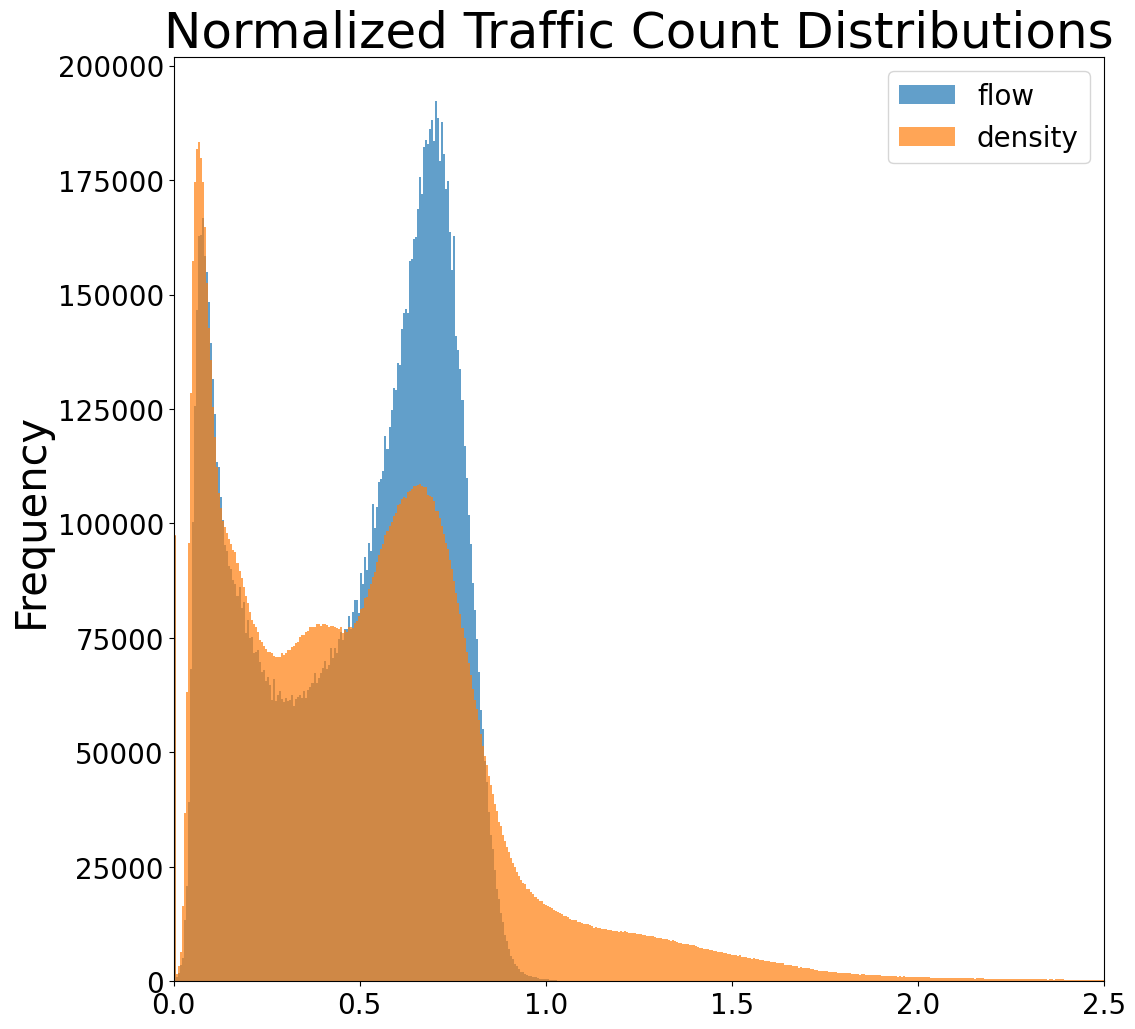

In [2]:
timeseries_df.loc[:, ['flow', 'density']].plot(
    figsize=(12,12),
    subplots=False,
    kind='hist',
    bins=1000,
    alpha=0.7,
    title='Normalized Traffic Count Distributions',
    xlim=[0,2.5],
    )

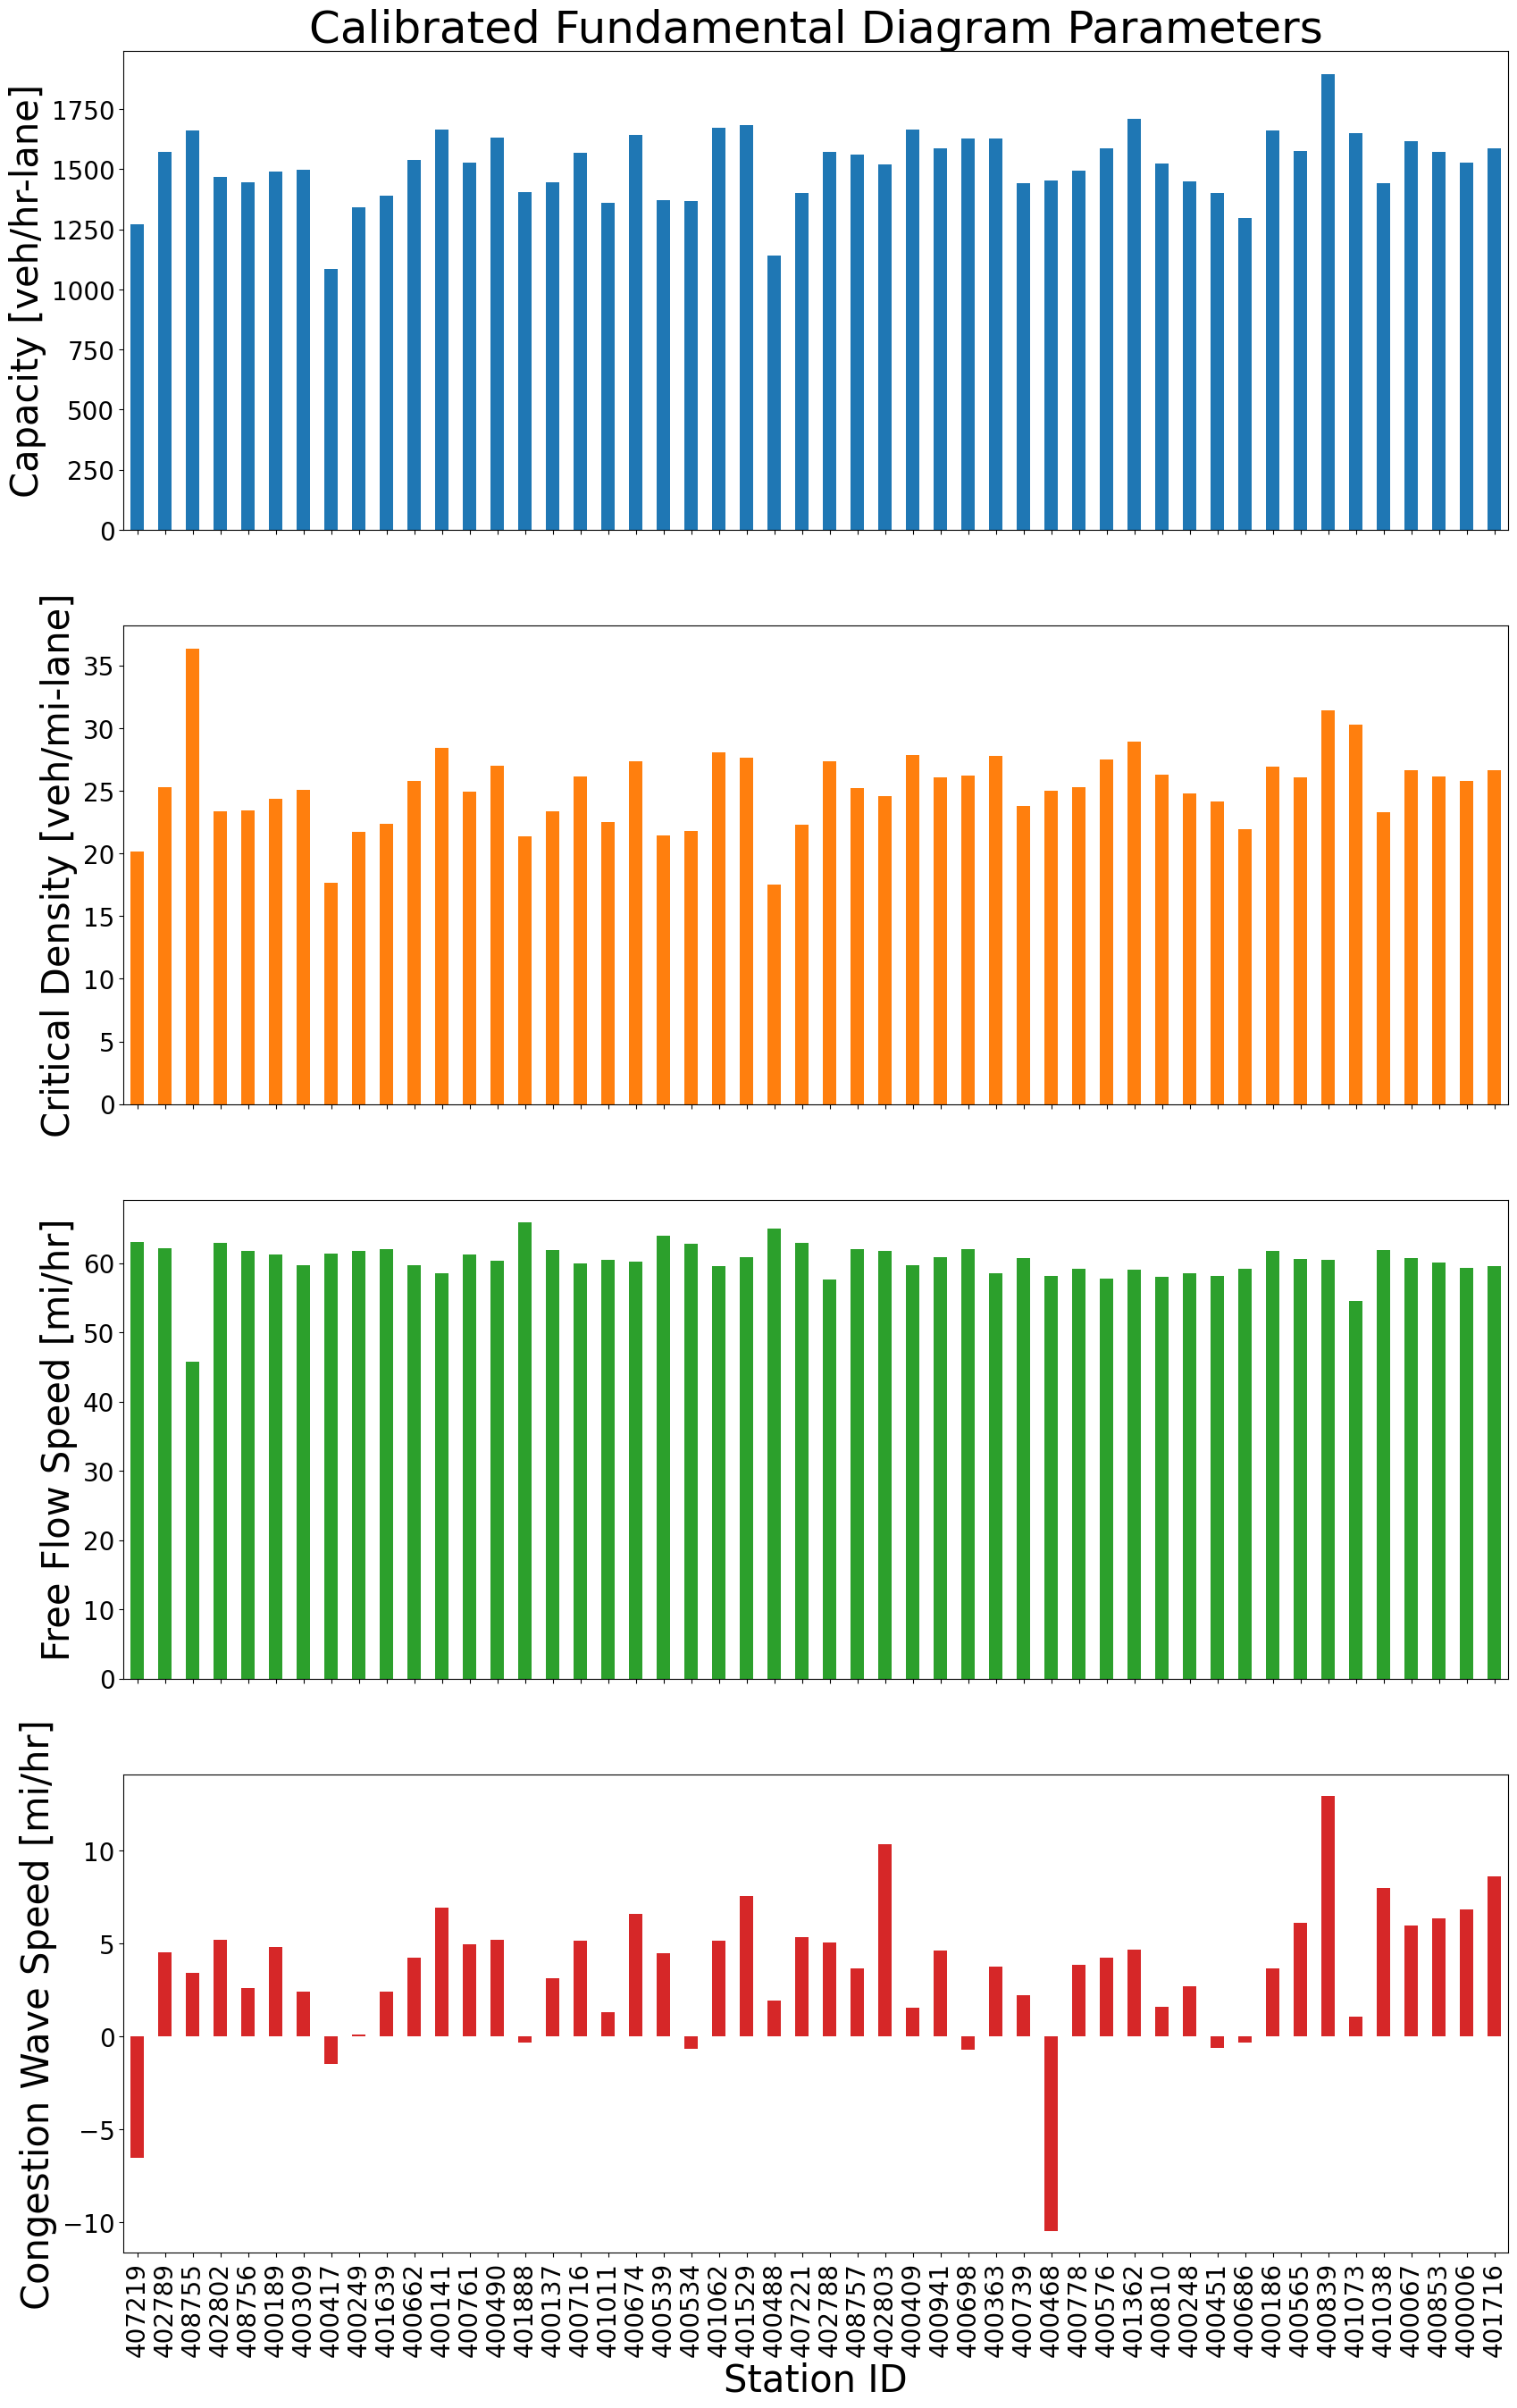

In [7]:
# Slice data
metadata_df = metadata_df.loc[metadata_df['capacity'].notna(), :]
metadata_df = metadata_df.sort_values(by=["Fwy", "Abs PM"])

# Make plots
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,32))
metadata_df["capacity"].plot(ax=axes[0], kind='bar', ylabel="Capacity [veh/hr-lane]", color='tab:blue')
metadata_df["critical_density"].plot(ax=axes[1], kind='bar', ylabel="Critical Density [veh/mi-lane]", color='tab:orange')
metadata_df["free_flow_speed"].plot(ax=axes[2], kind='bar', ylabel="Free Flow Speed [mi/hr]", color='tab:green')
metadata_df["congestion_wave_speed"].plot(ax=axes[3], kind='bar', ylabel="Congestion Wave Speed [mi/hr]", color='tab:red')

# Configure plot parameters
axes[0].set_title("Calibrated Fundamental Diagram Parameters")
axes[-1].tick_params(axis='x', rotation=90)

plt.show()

Show distribution and QQ plot for whitened timeseries

In [14]:
# Load df
whitened_df = pd.read_csv("/Users/robstallman/Downloads/whitened_data_long.csv")
print(whitened_df.head())

# Select data
whitened_flow = whitened_df['flow'].dropna()
x_flow = np.linspace(whitened_flow.min(), whitened_flow.max(), 100)
whitened_density = whitened_df['density'].dropna()
x_density = np.linspace(whitened_density.min(), whitened_density.max(), 100)

             timestamp  Station ID  pct_observed  Lanes      Type  Abs PM  \
0  2022-01-01 00:00:00      400006           0.0      4  Mainline   23.77   
1  2022-01-01 00:05:00      400006           0.0      4  Mainline   23.77   
2  2022-01-01 00:10:00      400006           0.0      4  Mainline   23.77   
3  2022-01-01 00:15:00      400006           0.0      4  Mainline   23.77   
4  2022-01-01 00:20:00      400006           0.0      4  Mainline   23.77   

   Length     capacity  free_flow_speed  congestion_wave_speed  \
0    0.34  1528.879025         59.34341               6.838261   
1    0.34  1528.879025         59.34341               6.838261   
2    0.34  1528.879025         59.34341               6.838261   
3    0.34  1528.879025         59.34341               6.838261   
4    0.34  1528.879025         59.34341               6.838261   

   critical_density  flow  density  
0         25.763249   NaN      NaN  
1         25.763249   NaN      NaN  
2         25.763249   NaN    

Text(0, 0.5, 'Sample Quantiles')

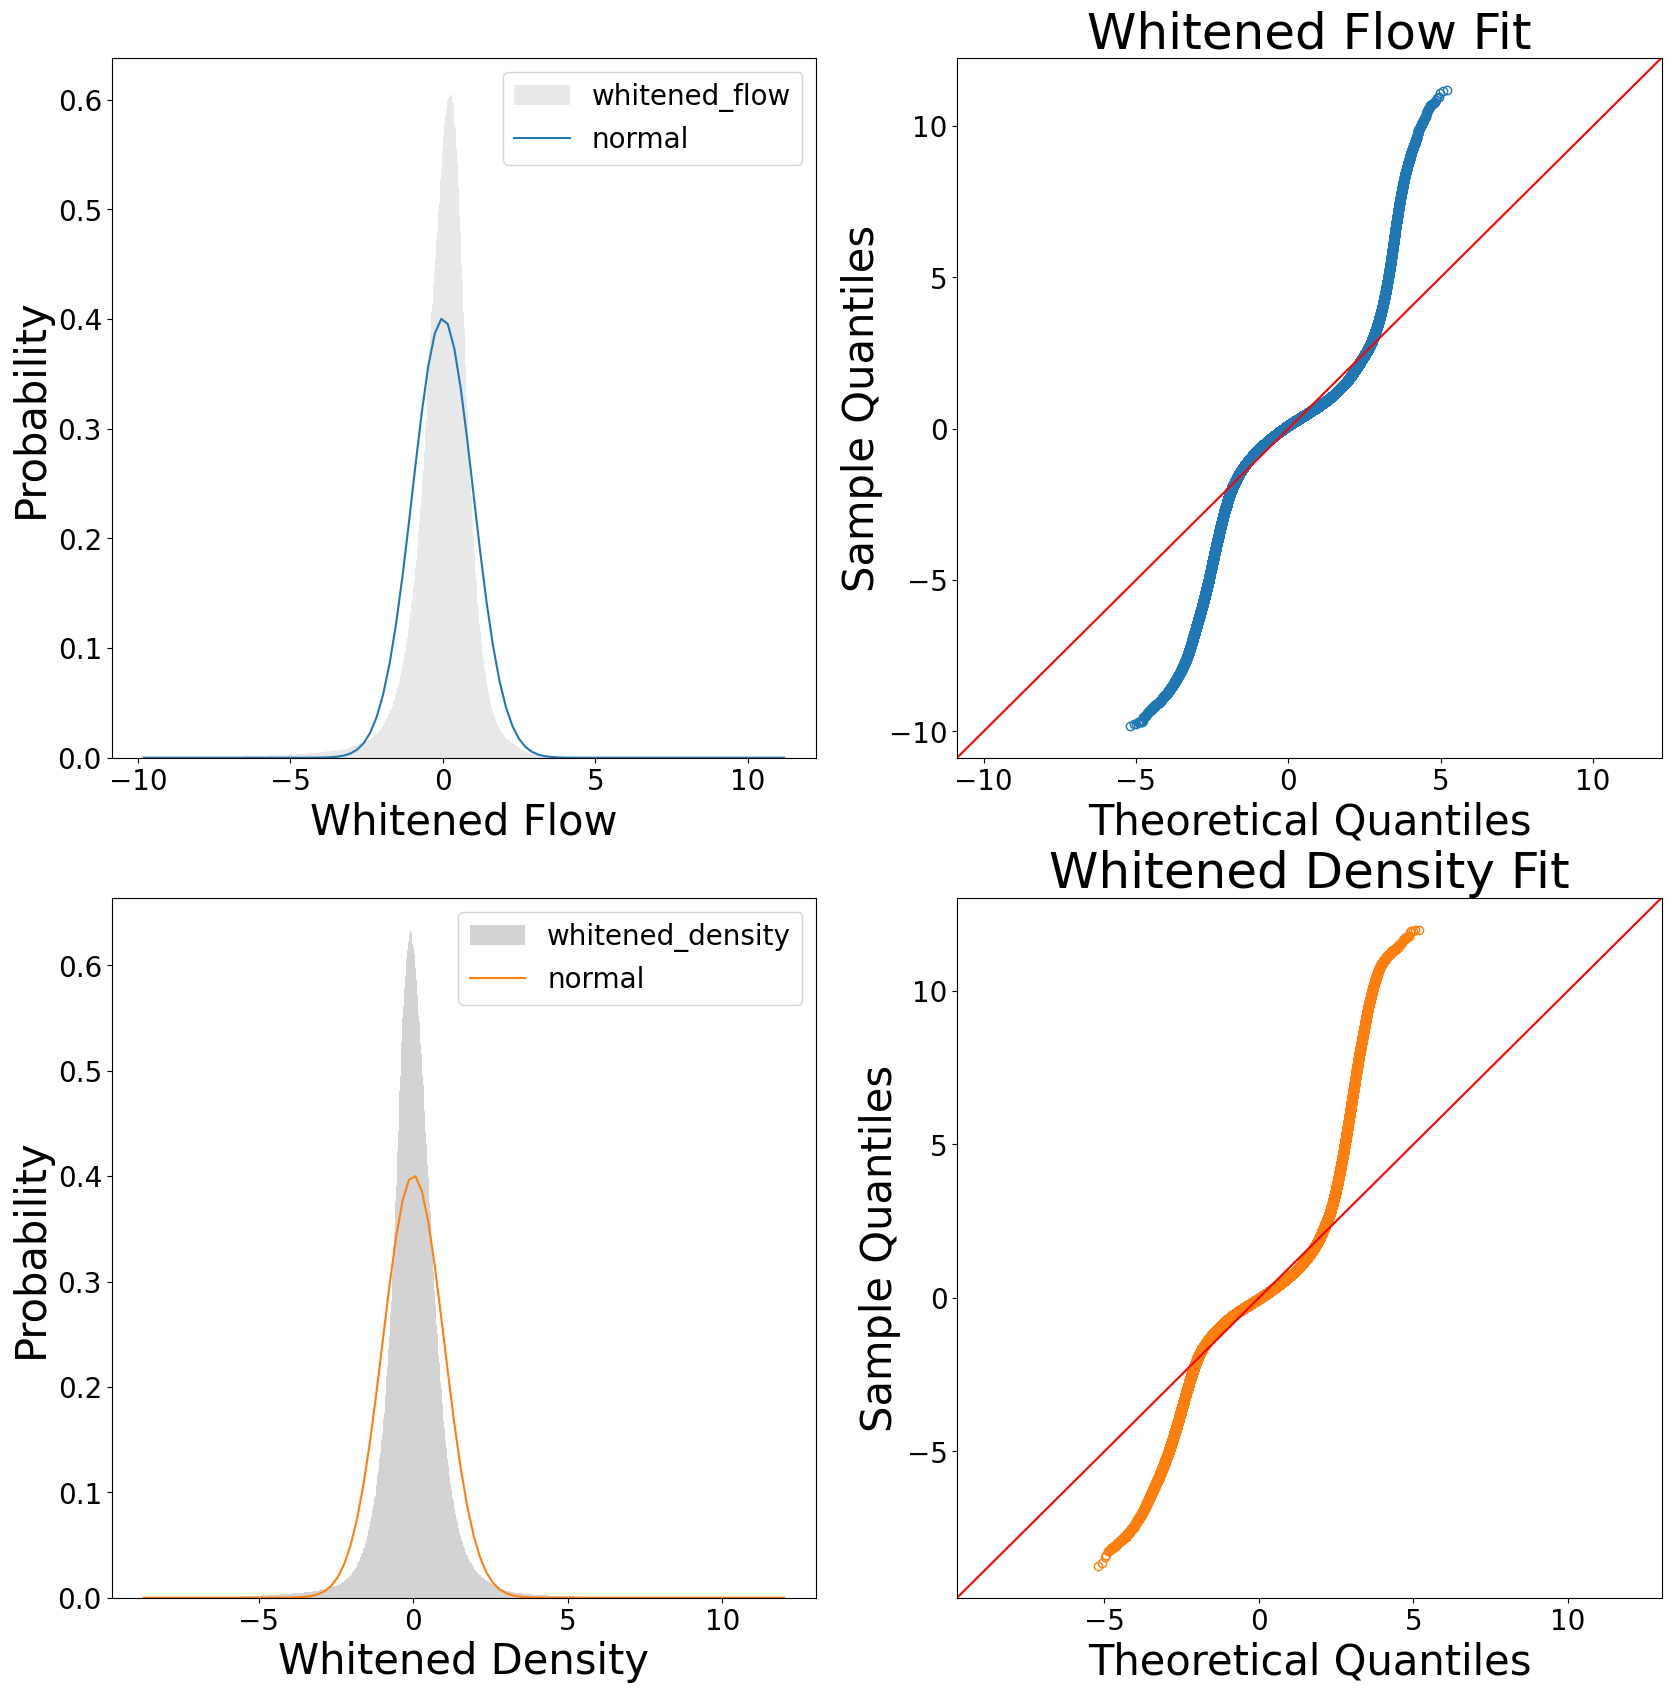

In [ ]:
# Generate histograms of the data
nbins=1000
fig, ((flow_hist_ax, flow_qq_ax), (density_hist_ax, density_qq_ax)) = plt.subplots(nrows=2, ncols=2, figsize=(20,20))
flow_hist_ax.hist(whitened_flow, bins=nbins, density=True, alpha=0.5, color='lightgrey', label='whitened_flow')
density_hist_ax.hist(whitened_density, bins=nbins, density=True, alpha=0.5, color='darkgrey', label='whitened_density')

# Fit a normal distribution to the data
mu_flow, sigma_flow = norm.fit(whitened_flow)
dist_flow = norm(mu_flow, sigma_flow)
pdf_flow = norm.pdf(x_flow, mu_flow, sigma_flow)
mu_density, sigma_density = norm.fit(whitened_density)
dist_density = norm(mu_density, sigma_density)
pdf_density = norm.pdf(x_density, mu_density, sigma_density)

# Plot the distribution
flow_hist_ax.plot(x_flow, pdf_flow, "tab:blue", label='normal')
density_hist_ax.plot(x_density, pdf_density, "tab:orange", label='normal')

# Plot the QQ plot
sm.qqplot(whitened_flow, dist=dist_flow, ax=flow_qq_ax, line='45', markerfacecolor='none', markeredgecolor='tab:blue')
sm.qqplot(whitened_density, dist=dist_density, ax=density_qq_ax, line='45', markerfacecolor='none', markeredgecolor='tab:orange')

# Add plot elements
flow_hist_ax.set_xlabel(f"Whitened Flow")
flow_hist_ax.set_ylabel("Probability")
flow_hist_ax.legend()
flow_qq_ax.set_title("Whitened Flow Fit")
flow_qq_ax.set_xlabel("Theoretical Quantiles")
flow_qq_ax.set_ylabel("Sample Quantiles")
density_hist_ax.set_xlabel(f"Whitened Density")
density_hist_ax.set_ylabel("Probability")
density_hist_ax.legend()
density_qq_ax.set_title("Whitened Density Fit")
density_qq_ax.set_xlabel("Theoretical Quantiles")
density_qq_ax.set_ylabel("Sample Quantiles")